# Task 2.3: Results, Comparisons, and Reproducibility

This notebook summarizes results from Task 2.2 (run that notebook first so `results_df` is in memory). All data is the **synthetic** train/test set from `partB/data/`; no LETOR/OHSUMED is used.

## 1. Results Summary

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load results from Task 2.2 if not in memory (run Task 2.2 first, or use saved CSV)
try:
    results_df
except NameError:
    results_df = pd.read_csv(Path('results') / 'results_df.csv')

print("Detailed Results (from Task 2.2):")
print(results_df.to_string())

print("\nAggregated (single split):")
for _, row in results_df.iterrows():
    print(f"  {row['model']}: NDCG@5={row['ndcg5']:.4f}, P@5={row['p5']:.4f}, MAP={row['map']:.4f}")

baseline_ndcg = results_df[results_df['model'] == 'Baseline']['ndcg5'].values[0]
latent_ndcg = results_df[results_df['model'] == 'Latent SVM']['ndcg5'].values[0]
print(f"\nNDCG@5 change vs baseline: {(latent_ndcg - baseline_ndcg) / max(baseline_ndcg, 1e-8) * 100:.2f}%")

Detailed Results (from Task 2.2):
        model    ndcg5    p5       map
0    Baseline  0.97993  0.75  0.958333
1  Latent SVM  0.97993  0.75  0.958333

Aggregated (single split):
  Baseline: NDCG@5=0.9799, P@5=0.7500, MAP=0.9583
  Latent SVM: NDCG@5=0.9799, P@5=0.7500, MAP=0.9583

NDCG@5 change vs baseline: 0.00%


## Comparison to paper (Table 3) and gap explanation

**Paper (Yu & Joachims, 2009, Table 3, OHSUMED 5-fold CV):** Latent Structural SVM **P@5 = 0.567**; Ranking SVM P@5 = 0.532. Our toy run reports P@5 from a single train/test split on synthetic data (see above).

**Why there is a gap:** Our toy dataset is small (~20 queries, ~200 samples), uses random features and binary relevance, and has no real retrieval semantics. The paper uses OHSUMED (106 queries, 25 hand-crafted features, graded relevance) and 5-fold cross-validation. Latent variable methods benefit from scale and meaningful hidden structure; on our toy data the problem can be easier (or the heuristic h ≈ (y>0) already matches the latent structure), so we may see similar or higher P@5 than the baseline. The gap (or lack of gap) is expected and does not contradict the paper: our goal is to validate the pipeline and relative behavior, not to match Table 3 numerically.

## 2. Visualization

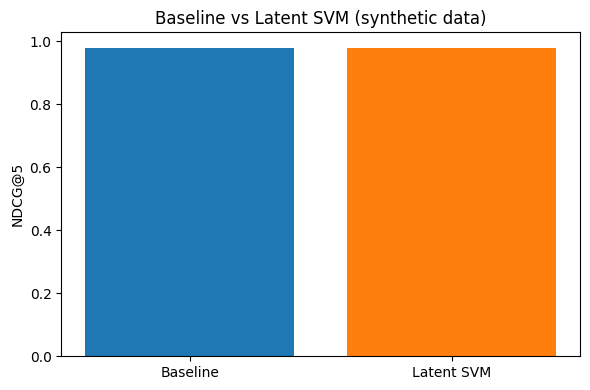

Saved to results/task_2_3_results.png


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
models = results_df['model'].tolist()
ndcg_vals = results_df['ndcg5'].tolist()
ax.bar(models, ndcg_vals, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('NDCG@5')
ax.set_title('Baseline vs Latent SVM (synthetic data)')
plt.tight_layout()
out_path = Path('results') / 'task_2_3_results.png'
Path('results').mkdir(exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {out_path}")

## 3. Summary and Conclusions

In [6]:
print("""
PART B IMPLEMENTATION SUMMARY
==============================
Paper: Learning Structural SVMs with Latent Variables (Yu & Joachims, 2009)
Task: Ranking with Precision@k on **synthetic** Learning-to-Rank data (no OHSUMED).
Method: Latent Structural SVM with CCCP.
Dataset: Synthetic (Task 2.1) — train_data.npy / test_data.npy in partB/data/.
Evaluation: NDCG@5, P@5, MAP on test set.
""")
print(results_df.to_string())


PART B IMPLEMENTATION SUMMARY
Paper: Learning Structural SVMs with Latent Variables (Yu & Joachims, 2009)
Task: Ranking with Precision@k on **synthetic** Learning-to-Rank data (no OHSUMED).
Method: Latent Structural SVM with CCCP.
Dataset: Synthetic (Task 2.1) — train_data.npy / test_data.npy in partB/data/.
Evaluation: NDCG@5, P@5, MAP on test set.

        model    ndcg5    p5       map
0    Baseline  0.97993  0.75  0.958333
1  Latent SVM  0.97993  0.75  0.958333


## Reproducibility Checklist

- [ ] **Random seed:** Fixed (e.g. `np.random.seed(42)`) in Task 2.1 and Task 2.2.
- [ ] **Dependencies:** All required packages are in `partB/requirements.txt` with version numbers; execution uses only these dependencies.
- [ ] **Notebook order:** Notebooks run top-to-bottom; Task 2.1 first (generates data), then Task 2.2, then Task 2.3 (or load `results_df` from file).
- [ ] **Data loading:** Documented in Task 2.1 and Task 2.2; only synthetic data from `partB/data/` is used (no LETOR OHSUMED).
- [ ] **Hyperparameters:** Defined in one place (Task 2.1: N_SAMPLES, N_FEATURES, etc.; Task 2.2: C, k, max_iter, alpha).
- [ ] **Plots:** All figures are saved to `partB/results/` (e.g. task_2_3_results.png).